# 💳 CreditRiskAI — Day 1: Business Framing & Data Cleaning Pipeline
**Project**: Give Me Some Credit (Default Risk Prediction)  
**Author**: Portfolio Project for GitHub & LinkedIn  
**Objective**: Establish business framing, audit data quality, and construct a robust preprocessing pipeline for credit delinquency risk modeling.

---

## 1. 🏢 Business Framing: The Lending Asymmetry Dilemma

In retail credit underwriting, financial institutions face an **asymmetric cost structure**:
* **Interest Margin**: Typically 8% – 15% per annum.
* **Loss on Default**: Up to 100% of unpaid principal plus recovery costs.
* A single defaulted loan often wipes out the net profit generated by **8 to 12 performing borrowers**.

### The Two Types of Errors
1. **False Negative (Type II Error - Critical Risk)**:
   * Model predicts *Non-Default (0)*, but borrower defaults *Default (1)*.
   * **Financial Impact**: Direct capital write-off, loan loss provisions (CKPN), collection costs.
2. **False Positive (Type I Error - Opportunity Loss)**:
   * Model predicts *Default (1)*, but applicant is creditworthy *Non-Default (0)*.
   * **Financial Impact**: Forgone interest revenue, customer churn to competitors.

### Business Objective
Build a predictive risk scoring engine that optimizes **default capture (ROC-AUC & Recall)** on highly imbalanced credit data (~6.7% default rate), providing granular risk tiers and explainable decisions.


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Add project root to path
sys.path.append(os.path.abspath('..'))
from src.data_cleaning import CreditDataCleaner

print("Libraries and cleaning module loaded successfully.")


Libraries and cleaning module loaded successfully.


---
## 2. 📂 Loading Raw Credit Datasets
We load the training set (`cs-training.csv`, 150,000 records) and the test set (`cs-test.csv`, 101,503 records).


In [2]:
train_raw = pd.read_csv('../datasets/cs-training.csv', index_col=0)
test_raw = pd.read_csv('../datasets/cs-test.csv', index_col=0)

print(f"Training Data Shape : {train_raw.shape[0]:,} rows, {train_raw.shape[1]} columns")
print(f"Test Data Shape     : {test_raw.shape[0]:,} rows, {test_raw.shape[1]} columns")
train_raw.head()


Training Data Shape : 150,000 rows, 11 columns
Test Data Shape     : 101,503 rows, 11 columns


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


---
## 3. 🔍 Data Health & Quality Audit

### 3.1 Target Distribution (Class Imbalance)
Let us evaluate the baseline default rate (`SeriousDlqin2yrs`).


                Borrower Count  Percentage (%)
Performing (0)          139974           93.32
Defaulted (1)            10026            6.68


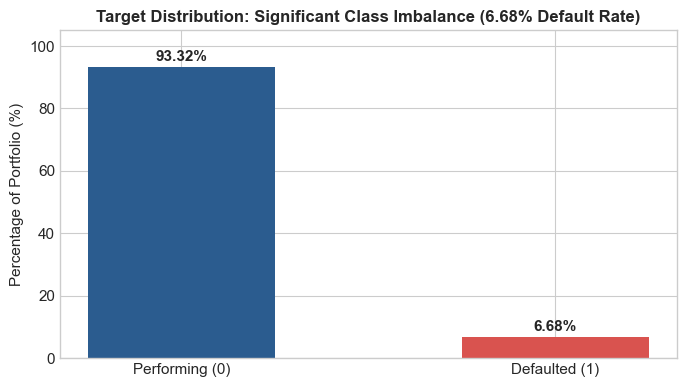

In [3]:
target_counts = train_raw['SeriousDlqin2yrs'].value_counts()
target_pct = train_raw['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Borrower Count': target_counts,
    'Percentage (%)': target_pct.round(2)
})
dist_df.index = ['Performing (0)', 'Defaulted (1)']
print(dist_df)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Performing (0)', 'Defaulted (1)'], target_pct, color=['#2b5c8f', '#d9534f'], width=0.5)
ax.set_ylabel('Percentage of Portfolio (%)')
ax.set_title('Target Distribution: Significant Class Imbalance (6.68% Default Rate)', fontsize=12, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()


### 3.2 Missing Value Analysis
Identify columns with missing data in both train and test sets.


In [4]:
missing_df = pd.DataFrame({
    'Train Missing Count': train_raw.isna().sum(),
    'Train Missing (%)': (train_raw.isna().mean() * 100).round(2),
    'Test Missing Count': test_raw.isna().sum(),
    'Test Missing (%)': (test_raw.isna().mean() * 100).round(2)
})
missing_df[missing_df['Train Missing Count'] > 0]


,Train Missing Count,Train Missing (%),Test Missing Count,Test Missing (%)
MonthlyIncome,29731,19.82,20103,19.81
NumberOfDependents,3924,2.62,2626,2.59


### 3.3 Concrete Anomalies Detected
1. **Age Anomaly (`age == 0`)**: 1 record in train has age 0 (data recording error).
2. **Bureau Error Codes (96 and 98)**: Exactly 269 records in delinquency columns have values 96 or 98 (standard credit bureau code for unreported/unavailable status).
3. **Extreme Utilization**: `RevolvingUtilizationOfUnsecuredLines` has max value 50,708 (over 100% limit in 3,321 records).
4. **Extreme DebtRatio**: Max value 329,664, typically occurring when income is missing.


In [5]:
print("Records with age == 0:", (train_raw['age'] == 0).sum())
print("Records with Bureau Codes 96/98:", (train_raw['NumberOfTimes90DaysLate'].isin([96, 98])).sum())
print("Records with Revolving Utilization > 1.0:", (train_raw['RevolvingUtilizationOfUnsecuredLines'] > 1.0).sum())
print("Records with DebtRatio > 1,000:", (train_raw['DebtRatio'] > 1000).sum())


Records with age == 0: 1
Records with Bureau Codes 96/98: 269
Records with Revolving Utilization > 1.0: 3321
Records with DebtRatio > 1,000: 16892


---
## 4. ⚙️ Executing Production Preprocessing Pipeline

We apply the modular `CreditDataCleaner` defined in `src/data_cleaning.py`.
### Cleaning Strategy:
1. **Age**: Replace `0` with NaN, impute with training median age.
2. **Delinquency Codes**: Create indicator `HasPastDueRecordError` and replace 96/98 with 0.
3. **Utilization**: Create indicator `RevolvingUtilizationOverLimit`, cap at 99th percentile.
4. **Monthly Income**: Create indicator `MonthlyIncome_is_missing`, impute via age cohort medians.
5. **Debt Ratio**: Create indicator `DebtRatio_is_extreme`, cap at 99th percentile.
6. **Dependents**: Create indicator `NumberOfDependents_is_missing`, impute missing with 0.


In [6]:
cleaner = CreditDataCleaner(util_cap_quantile=0.99, debt_cap_quantile=0.99)

# Fit on train, transform on train and test (avoiding data leakage)
train_cleaned = cleaner.fit_transform(train_raw)
test_cleaned = cleaner.transform(test_raw)

print(f"Cleaned Train Shape: {train_cleaned.shape}")
print(f"Cleaned Test Shape : {test_cleaned.shape}")


Cleaned Train Shape: (150000, 16)
Cleaned Test Shape : (101503, 16)


---
## 5. ✅ Post-Cleaning Verification & Sanity Checks


In [7]:
print("Remaining Missing Values in Train:")
print(train_cleaned.isna().sum())

print("\n--- Summary Statistics of Transformed Predictors ---")
train_cleaned[['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'NumberOfDependents']].describe().T[['mean', 'std', 'min', '50%', 'max']]


Remaining Missing Values in Train:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
HasPastDueRecordError                   0
RevolvingUtilizationOverLimit           0
MonthlyIncome_is_missing                0
DebtRatio_is_extreme                    0
NumberOfDependents_is_missing           0
dtype: int64

--- Summary Statistics of Transformed Predictors ---


,mean,std,min,50%,max
age,52.295553,14.771249,21.0,52.000000,1.090000e+02
RevolvingUtilizationOfUnsecuredLines,0.320496,0.352152,0.0,0.154181,1.092956e+00
DebtRatio,316.548869,906.962222,0.0,0.366508,4.979040e+03
MonthlyIncome,6425.588080,12894.974476,0.0,5313.000000,3.008750e+06
NumberOfDependents,0.737413,1.107021,0.0,0.000000,2.000000e+01


---
## 6. 💾 Persisting Cleaned Datasets
Save the sanitized datasets into `data/processed/` for Day 2 EDA and Day 3 Modeling.


In [8]:
os.makedirs('../data/processed', exist_ok=True)

train_cleaned.to_csv('../data/processed/train_cleaned.csv', index=False)
test_cleaned.to_csv('../data/processed/test_cleaned.csv', index=False)

print("Cleaned datasets saved successfully:")
print(" - data/processed/train_cleaned.csv")
print(" - data/processed/test_cleaned.csv")


Cleaned datasets saved successfully:
 - data/processed/train_cleaned.csv
 - data/processed/test_cleaned.csv


---
## 🎯 Day 1 Milestone Complete!
- ✅ **Business Framing Established**: Framed the 14:1 imbalanced risk problem and asymmetric loss function.
- ✅ **Data Quality Audited**: Identified missing values, bureau codes 96/98, zero-age anomaly, and extreme leverage points.
- ✅ **Modular Pipeline Built**: `src/data_cleaning.py` transforms raw data without data leakage.
- ✅ **Engineered Risk Flags**: Created 5 indicator variables to preserve anomaly signal for downstream modeling.
- ⏭️ **Next Step (Day 2)**: Comprehensive Exploratory Data Analysis (EDA), risk cohort segmentation (Age, Income, Credit Line Mix), and extracting 3-5 core business insights.
